# GIT dependency


In [8]:
!git clone https://github.com/MiguelPartosa/Thesis-FOS-BinaryClass-WSD.git

[WinError 3] The system cannot find the path specified: 'Thesis-FOS-BinaryClass-WSD/Ensemble Model/'
c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\Thesis-FOS-BinaryClass-WSD\Ensemble Model


c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


# Load Models and Libraries


In [1]:
%cd Thesis-FOS-BinaryClass-WSD/Ensemble Model/

c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\Thesis-FOS-BinaryClass-WSD\Ensemble Model


c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Sentence Transformer -- Sentence Embeddings


In [3]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('sentence-transformers/LaBSE')

c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Processing


## Load Dataset


In [ ]:
df_test = pd.read_excel('../../Dataset/Test_Set_WLabels.xlsx')
df_train = pd.read_excel('../../Dataset/Train_Set_WLabels.xlsx')
display(df_test.head(1), df_test.shape, df_train.head(1), df_train.shape)

,FOS,Word Sense,Verb,Usage,Is FOS
0,anak sa sala,usa ka anak nga dili-konsejero,['sala'],Ang anak sa sala nga si Maria kay ginaatiman g...,1


(322, 5)

,FOS,Word Sense,Verb,Usage,Is FOS
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1


(1288, 5)

## Sentence Transformer


Removing the label column from the dataset for clarity


In [5]:
# df_train.drop(columns=['Is FOS'], inplace=True)
df = df_train.copy()

In [6]:
# df['Word Sense'] = df['Word Sense']
df.head(3)

,FOS,Word Sense,Verb,Usage,Is FOS
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1
1,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Nagpalit siya og balayronon sa papel sa tindah...,0
2,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],"""Ang silingan murag namiya og tai, kalit lang ...",1


The embeddings are explicitly normalized so that


### Generate Embeddings and Similarity Columns


> An alteration from the previously shown way of retrieving the embeddings are its normalization to work with PCA and containing all the new columns to be generated from embeddings and similarity score into one function.


In [ ]:
def GetEmbeddings(words: str) -> np.ndarray:
    return embedding_model.encode(words, normalize_embeddings=True)


def ComputeSimilarity(embedding1, embedding2):
    return embedding_model.similarity(embedding1, embedding2)

In [ ]:
def RetrieveEmbeddings(df) -> pd.DataFrame:
    df_embeddings = df.copy()
    df_embeddings['Sentence Embeddings'] = df['Word Sense'].apply(
        GetEmbeddings)
    df_embeddings['Verb Embeddings'] = df['Verb'].apply(GetEmbeddings)
    df_embeddings['Usage Embeddings'] = df['Usage'].apply(GetEmbeddings)
    df_embeddings['Similarity Scores'] = df_embeddings.apply(lambda row: ComputeSimilarity(
        row['Sentence Embeddings'], row['Usage Embeddings']), axis=1)
    return df_embeddings


df_embedded = RetrieveEmbeddings(df)
df_embedded.head(3)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1,"[0.004979501, -0.03455616, 0.044118445, -0.056...","[-0.028341336, -0.006864522, -0.008147446, -0....","[-0.027987016, -0.007430709, 0.023322027, 0.01...",[[tensor(0.4529)]]
1,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Nagpalit siya og balayronon sa papel sa tindah...,0,"[0.004979501, -0.03455616, 0.044118445, -0.056...","[-0.028341336, -0.006864522, -0.008147446, -0....","[-0.053077772, -0.042660423, -0.037503656, -0....",[[tensor(0.3356)]]
2,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],"""Ang silingan murag namiya og tai, kalit lang ...",1,"[-0.03320765, -0.006950153, 0.012191928, 0.016...","[-0.02244177, 0.010921938, -0.016191624, -0.04...","[-0.01381951, 0.021733848, -0.01817845, 0.0346...",[[tensor(0.3334)]]


In [ ]:
df_embedded.to_excel(
    '../../Dataset/Ensemble/train_with_embeddings.xlsx', index=False)

## Checkpoint for dataset


In [ ]:
df_embedded = pd.read_excel(
    '../../Dataset/Ensemble/train_with_embeddings.xlsx')
df_embedded.head(1)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1,[ 0.0049795 -0.03455616 0.04411845 -0.056273...,[-2.83413362e-02 -6.86452212e-03 -8.14744644e-...,[-2.79870164e-02 -7.43070897e-03 2.33220272e-...,tensor([[0.4529]])


Turning our formatted embeddings as strings back into the original tensor format


In [5]:
def ConvertToNp(string_tensor):
    return np.fromstring(string_tensor.strip("[]"), sep=" ")


df_embedded['Sentence Embeddings'] = df_embedded['Sentence Embeddings'].apply(
    ConvertToNp)
df_embedded['Verb Embeddings'] = df_embedded['Verb Embeddings'].apply(
    ConvertToNp)
df_embedded['Usage Embeddings'] = df_embedded['Usage Embeddings'].apply(
    ConvertToNp)

# Checking to see if the columns are successfully converted
display(type(df_embedded.iloc[0, 5]), type(
    df_embedded.iloc[0, 6]), type(df_embedded.iloc[0, 7]))

numpy.ndarray

numpy.ndarray

numpy.ndarray

## PCA-Guided K-means


### Transforming Embeddings Columns

- Before taking the embeddings as input for the dimensionality reduction using PCA, we must turn the embeddings columns to dataframes with the size of `(1288,768)` each


In [6]:
def GeneratePCA(col_name: str, col_val: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame()
    # To visualize the transformation
    for col in tqdm(col_val, desc=f'Transforming embeddings for {col_name}'):
        new_row_val = []
        new_row_column_name = []
        for idx, embedding in enumerate(col):
            new_row_column_name.append(str(col_name + f' {idx + 1}'))
            new_row_val.append(embedding)
        df = pd.concat([df,
                        pd.DataFrame(
                            [new_row_val], columns=new_row_column_name)
                        ])
    return df.reset_index(drop=True)


# We make three dataframes for each embedding column
df_pca_sentence = pd.DataFrame(GeneratePCA(
    'Sentence Embeddings', df_embedded['Sentence Embeddings']))
df_pca_verb = pd.DataFrame(GeneratePCA(
    'Verb Embeddings', df_embedded['Verb Embeddings']))
df_pca_usage = pd.DataFrame(GeneratePCA(
    'Usage Embeddings', df_embedded['Usage Embeddings']))
display(df_pca_sentence.head(3), df_pca_usage.head(3), df_pca_verb.head(3))

Transforming embeddings for Usage Embeddings: 100%|██████████| 1288/1288 [00:11<00:00, 112.80it/s]


,Sentence Embeddings 1,Sentence Embeddings 2,Sentence Embeddings 3,Sentence Embeddings 4,Sentence Embeddings 5,Sentence Embeddings 6,Sentence Embeddings 7,Sentence Embeddings 8,Sentence Embeddings 9,Sentence Embeddings 10,...,Sentence Embeddings 759,Sentence Embeddings 760,Sentence Embeddings 761,Sentence Embeddings 762,Sentence Embeddings 763,Sentence Embeddings 764,Sentence Embeddings 765,Sentence Embeddings 766,Sentence Embeddings 767,Sentence Embeddings 768
0,0.004980,-0.034556,0.044118,-0.056274,-0.032296,-0.028854,-0.022767,0.032210,-0.038238,-0.007559,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
1,0.004980,-0.034556,0.044118,-0.056274,-0.032296,-0.028854,-0.022767,0.032210,-0.038238,-0.007559,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
2,-0.033208,-0.006950,0.012192,0.016079,0.056162,-0.025116,-0.062095,-0.045542,-0.007492,-0.020981,...,0.033325,0.000843,-0.03505,-0.030099,-0.025864,-0.017886,-0.059123,-0.005189,-0.019514,-0.015873


,Usage Embeddings 1,Usage Embeddings 2,Usage Embeddings 3,Usage Embeddings 4,Usage Embeddings 5,Usage Embeddings 6,Usage Embeddings 7,Usage Embeddings 8,Usage Embeddings 9,Usage Embeddings 10,...,Usage Embeddings 759,Usage Embeddings 760,Usage Embeddings 761,Usage Embeddings 762,Usage Embeddings 763,Usage Embeddings 764,Usage Embeddings 765,Usage Embeddings 766,Usage Embeddings 767,Usage Embeddings 768
0,-0.027987,-0.007431,0.023322,0.017849,-0.049737,0.010092,-0.041104,-0.024007,-0.009431,0.054412,...,0.004159,0.005345,0.033418,0.037980,0.033858,0.007581,-0.030523,0.033182,0.021052,-0.025854
1,-0.053078,-0.042660,-0.037504,-0.046349,-0.035331,-0.025625,-0.062610,-0.046871,0.033949,0.010346,...,0.042831,0.027119,-0.014229,0.007455,0.024552,-0.031171,-0.009589,-0.063938,0.006921,0.011817
2,-0.013820,0.021734,-0.018178,0.034688,-0.004160,0.019424,-0.029084,0.014665,0.059071,-0.044792,...,0.003249,0.071950,0.014779,0.034981,-0.009357,0.029682,0.009591,0.031418,0.019491,-0.050644


,Verb Embeddings 1,Verb Embeddings 2,Verb Embeddings 3,Verb Embeddings 4,Verb Embeddings 5,Verb Embeddings 6,Verb Embeddings 7,Verb Embeddings 8,Verb Embeddings 9,Verb Embeddings 10,...,Verb Embeddings 759,Verb Embeddings 760,Verb Embeddings 761,Verb Embeddings 762,Verb Embeddings 763,Verb Embeddings 764,Verb Embeddings 765,Verb Embeddings 766,Verb Embeddings 767,Verb Embeddings 768
0,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.029226,0.028634,0.002660,0.050883,0.011894,-0.055575,-0.005229,-0.005603,-0.006009,-0.035409
1,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.029226,0.028634,0.002660,0.050883,0.011894,-0.055575,-0.005229,-0.005603,-0.006009,-0.035409
2,-0.022442,0.010922,-0.016192,-0.042995,-0.014828,-0.030193,-0.043392,-0.023752,-0.068112,-0.048461,...,-0.020682,0.014295,0.030947,0.001746,0.054406,-0.036888,-0.030826,0.013990,-0.035365,-0.013312


#### Combining Embeddings

Combined plot for the embeddings


In [56]:
df_combined_embeddings = df_pca_verb.join(df_pca_usage.join(df_pca_sentence))
df_combined_embeddings.head(3)

,Verb Embeddings 1,Verb Embeddings 2,Verb Embeddings 3,Verb Embeddings 4,Verb Embeddings 5,Verb Embeddings 6,Verb Embeddings 7,Verb Embeddings 8,Verb Embeddings 9,Verb Embeddings 10,...,Sentence Embeddings 759,Sentence Embeddings 760,Sentence Embeddings 761,Sentence Embeddings 762,Sentence Embeddings 763,Sentence Embeddings 764,Sentence Embeddings 765,Sentence Embeddings 766,Sentence Embeddings 767,Sentence Embeddings 768
0,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
1,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
2,-0.022442,0.010922,-0.016192,-0.042995,-0.014828,-0.030193,-0.043392,-0.023752,-0.068112,-0.048461,...,0.033325,0.000843,-0.03505,-0.030099,-0.025864,-0.017886,-0.059123,-0.005189,-0.019514,-0.015873


### Correlation Plot

- To address the comment/suggestion made by Engr. Andrei Martin P. Diamante during the 50% implementation defense, a correlation matrix will show the necessity of include a correlation of the columns from the embeddings


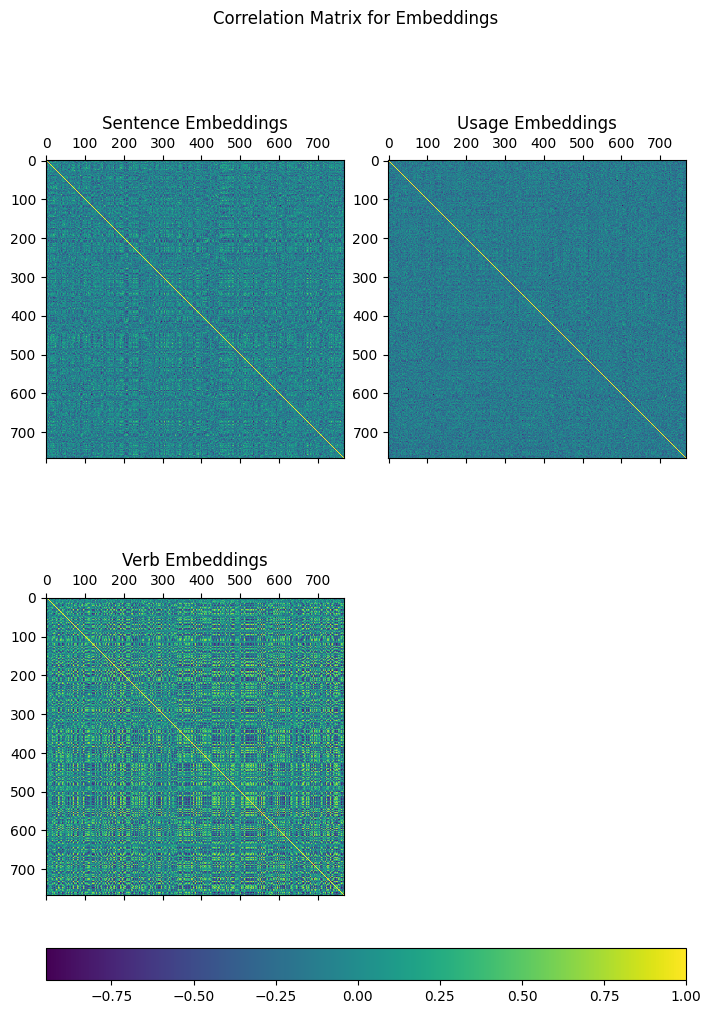

In [237]:

from matplotlib import colors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

fig, axs = plt.subplots(2, 2, figsize=(7, 10), layout='constrained')

# ColorBar


# datasets will contain all the values of the embeddings dataframes in one numpy array
datasets = [np.concatenate((df_pca_sentence.corr().to_numpy(),
            df_pca_verb.corr().to_numpy(),
            df_pca_usage.corr().to_numpy()), axis=1)]
# create a single norm to be shared across all images

norm = colors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))
images = []
for ax, data in zip(axs.flat, datasets):
    images.append(ax.imshow(data, norm=norm))

fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.1)

def PlotCorrelationMatrix(df, title:str, position:tuple):
    axs[*position].matshow(pd.DataFrame(scaler.fit_transform(df)).corr())
    axs[*position].set_title(f'{title} Embeddings')

PlotCorrelationMatrix(df_pca_sentence, title='Sentence', position=(0,0))
PlotCorrelationMatrix(df_pca_verb, title='Verb', position=(1,0))
PlotCorrelationMatrix(df_pca_usage, title='Usage', position=(0,1))

axs[1, 1].axis('off')

fig.suptitle('Correlation Matrix for Embeddings')

plt.show()

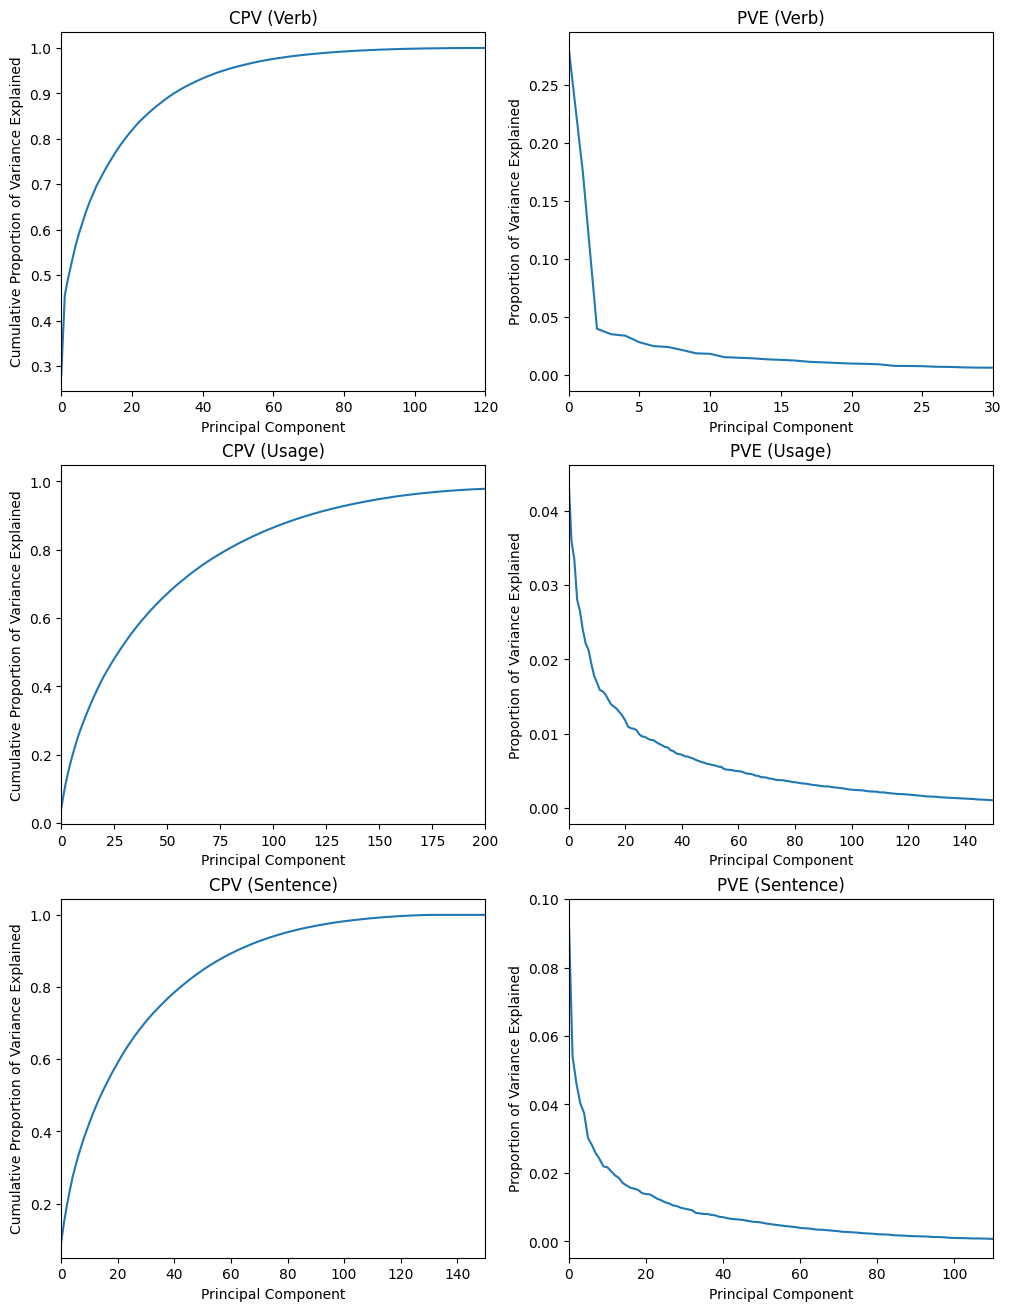

In [200]:
from sklearn.decomposition import PCA
pca = PCA()


def GetExplainedVariance(df):
    raw_scaled = scaler.fit_transform(df)
    pca.fit(raw_scaled)
    return pca.explained_variance_ratio_


def GetCumulativeVariance(df):
    return np.cumsum(GetExplainedVariance(df))


fig, axs = plt.subplots(3, 2, figsize=(10, 13), layout='constrained')


def PlotVariance(df, title: str, row: int, xlim_proportion: int = None, xlim_cumulative: int = None):
    # Plot 1 cumulative var     
    axs[row, 0].plot(GetCumulativeVariance(df))
    axs[row, 0].set_title(
        f'CPV ({title})')
    if xlim_cumulative is not None:
        axs[row, 0].set_xlim(left=0,right=xlim_cumulative)
    axs[row, 0].set_ylabel("Cumulative Proportion of Variance Explained")
    axs[row, 0].set_xlabel("Principal Component")
    
    # Plot 2 explained var
    axs[row, 1].plot(GetExplainedVariance(df))
    axs[row, 1].set_title(f'PVE ({title})')
    if xlim_proportion is not None:
        axs[row, 1].set_xlim(left=0,right=xlim_proportion)
    axs[row, 1].set_ylabel("Proportion of Variance Explained")
    axs[row, 1].set_xlabel("Principal Component")


# Verb Embeddings
PlotVariance(df_pca_verb, row=0, title='Verb', xlim_cumulative=120, xlim_proportion=30)
PlotVariance(df_pca_usage, row=1, title='Usage', xlim_cumulative=200, xlim_proportion=150)
PlotVariance(df_pca_sentence, row=2, title='Sentence', xlim_cumulative=150, xlim_proportion=110)

plt.show()

In [245]:
pd.DataFrame(GetExplainedVariance(df_pca_verb))

,0
0,0.281546
1,0.174535
2,0.039455
3,0.034755
4,0.033456
5,0.027828
6,0.024490
7,0.023774
8,0.021174
9,0.018290


In [243]:
def ShowExplainedProportion(df, idx, title):
    return f"{idx} Components for {title} Embeddings account for {pd.DataFrame(GetExplainedVariance(df)).iloc[idx-1].item():.5f}% of Variability" 

display(
    ShowExplainedProportion(df_pca_verb, 1, 'Verb'),
    ShowExplainedProportion(df_pca_usage, 1, 'Usage'),
    ShowExplainedProportion(df_pca_sentence, 1, 'Sentence'),
)

'1 Components for Verb Embeddings account for 0.28155% of Variability'

'1 Components for Usage Embeddings account for 0.04397% of Variability'

'1 Components for Sentence Embeddings account for 0.09540% of Variability'

In [190]:
def GetIndexOfProportion(df, value, title):
    df_index = pd.DataFrame(GetCumulativeVariance(df)).loc[lambda df: df[0] > value].idxmin().item()
    return f"Index {df_index} or {df_index + 1} number of principal components for {title} has a cumulutive proportion variance {value}> with a value of {pd.DataFrame(GetCumulativeVariance(df)).iloc[df_index].item()}" 

display(
    GetIndexOfProportion(df_pca_verb, 0.8, 'Verb'),
    GetIndexOfProportion(df_pca_usage, 0.8, 'Usage'),
    GetIndexOfProportion(df_pca_sentence, 0.8, 'Sentence'),
)

'Index 19 or 20 number of principal components for Verb has a cumulutive proportion variance 0.8> with a value of 0.809727595326846'

'Index 79 or 80 number of principal components for Usage has a cumulutive proportion variance 0.8> with a value of 0.8030759433598151'

'Index 43 or 44 number of principal components for Sentence has a cumulutive proportion variance 0.8> with a value of 0.8056109430894018'

### PCA Selection
Given the above results from each embedding set's principal components for selection.
| Embedding Set      | Number of Principal  Components      | Equivalent Cumulative Proportion      |
| ------------- | ------------- | ------------- |
| Verb | 20 | 0.809727595326846 |
| Usage | 80 | 0.8030759433598151 |
| Sentence | 44 | 0.8056109430894018 |

### Clusters With K-means

- Citation: [medium article by Wamika Jha](https://medium.com/analytics-vidhya/implementation-of-principal-component-analysis-pca-in-k-means-clustering-b4bc0aa79cb6)


#### Elbow method: WCSS for each Embeddings Set

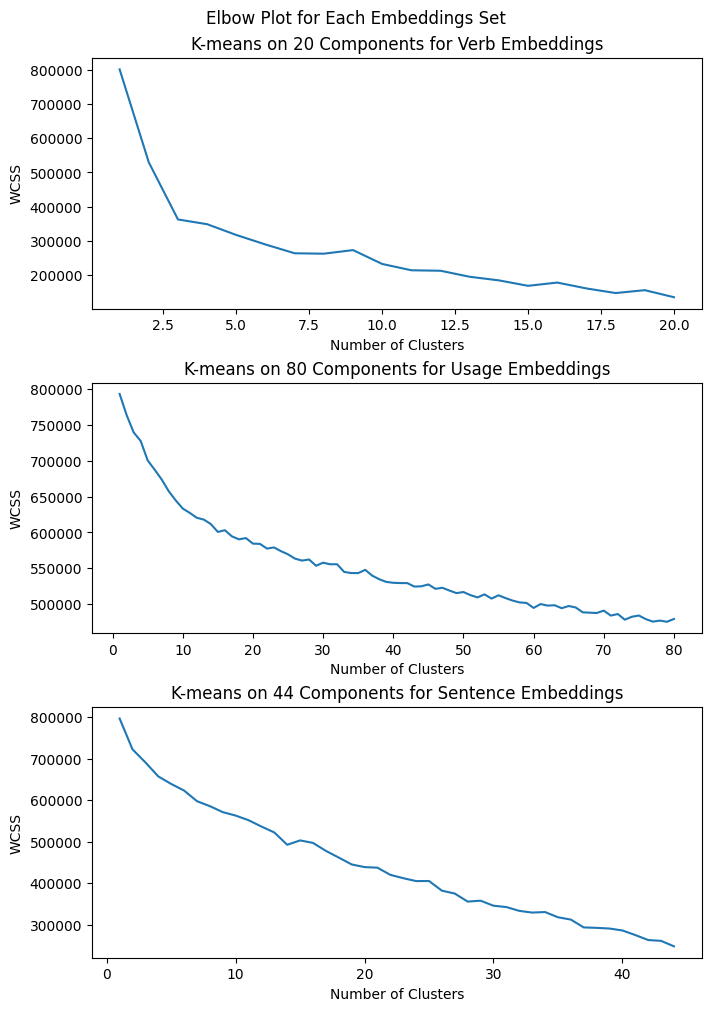

In [249]:

def PlotClusters(df, ax:np.ndarray, components: int, title:str):
    df = pd.DataFrame(PCA(n_components=components).fit(scaler.fit_transform(df)).transform(scaler.fit_transform(df)))
    wcss = []
    for i in range(1, components+1):
        model = KMeans(n_clusters=i, init="k-means++")
        model.fit(df)
        wcss.append(model.inertia_)
        
    ax.plot(range(1, components+1), wcss)
    ax.set_ylabel('WCSS')
    ax.set_xlabel('Number of Clusters')
    ax.set_title(f'K-means on {components} Components for {title} Embeddings')


fig, axs = plt.subplots(3, 1, figsize=(7, 10), layout='constrained')


PlotClusters(df_pca_verb, ax=axs[0], components=20, title='Verb')
PlotClusters(df_pca_usage, ax=axs[1],components=80,title='Usage')
PlotClusters(df_pca_sentence, ax=axs[2],components=44,title='Sentence')

# axs[1].set_xlim(0,30)
# axs[2].set_xlim(0,10)

plt.suptitle('Elbow Plot for Each Embeddings Set')
plt.show()

From the graph of WCSS, it's hard to tell what number of clusters are optimal for the second two embeddings. We will proceed with Silhouette scores.

#### Silhouette Analysis

Optimal K for: 
Verb: 5 (score: 0.533)
Usage: 17 (score: 0.081)
Sentence: 44 (score: 0.435)


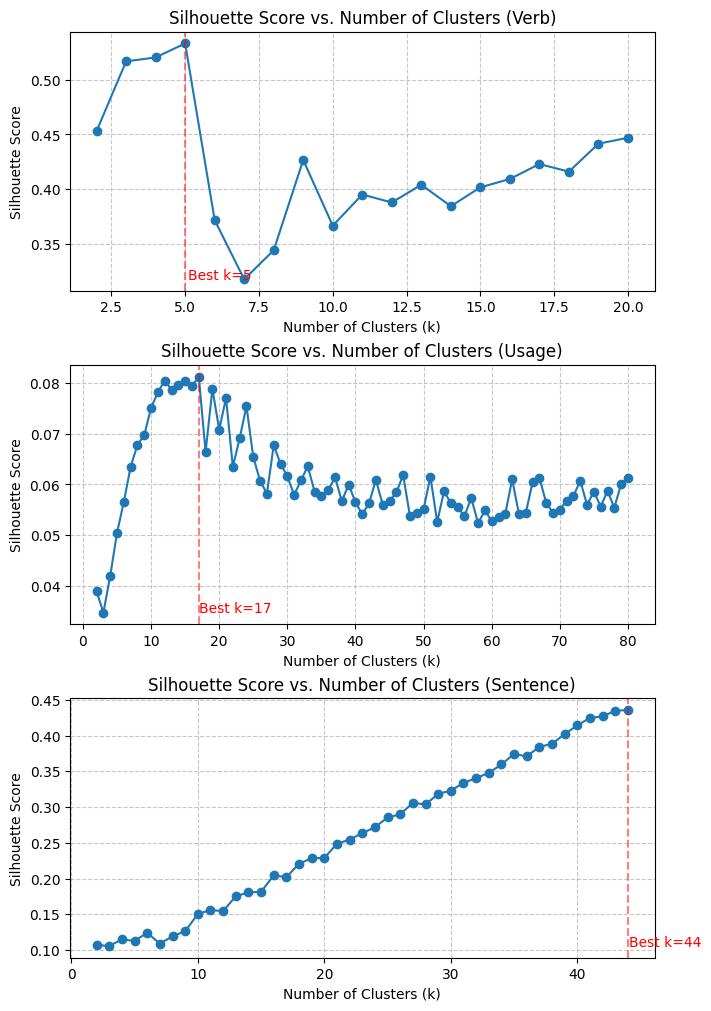

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
fig, axs = plt.subplots(3, 1, figsize=(7, 10), layout='constrained')
scaler = StandardScaler()

def GenerateClusterSilhouette(df, max_clusters, ax, title):
    best_k, best_score = 2, -1 
    scores = []
    pca_df = pd.DataFrame(PCA(n_components=max_clusters).fit(scaler.fit_transform(df)).transform(scaler.fit_transform(df)))
    
    for k in range(2, max_clusters + 1):
        # For reporoducibility
        model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = model.fit_predict(pca_df)
        
        # Check if we have enough samples for silhouette score
        if len(np.unique(labels)) > 1:  
            score = silhouette_score(pca_df, labels)
            scores.append(score)
            
            if score > best_score:
                best_k, best_score = k, score
        else:
            scores.append(0)  
    
    
    ax.plot(range(2, max_clusters + 1), scores, marker='o')
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_title(f"Silhouette Score vs. Number of Clusters ({title})")
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Best K
    ax.axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    ax.text(best_k+0.1, min(scores), f'Best k={best_k}', color='r')
    
    return best_k, best_score

# Use different dataframes for each analysis
verb_k, verb_score = GenerateClusterSilhouette(df_pca_verb, max_clusters=20, ax=axs[0], title='Verb')
usage_k, usage_score = GenerateClusterSilhouette(df_pca_usage, ax=axs[1], max_clusters=80, title='Usage')
sentence_k, sentence_score = GenerateClusterSilhouette(df_pca_sentence, ax=axs[2], max_clusters=44, title='Sentence')

print(f'Optimal K for: \nVerb: {verb_k} (score: {verb_score:.3f})\nUsage: {usage_k} (score: {usage_score:.3f})\nSentence: {sentence_k} (score: {sentence_score:.3f})')

plt.show()

### Generate Finalized PCA-Guided K-means Columns

In [268]:
def GenerateGuidedPCA(df,components:int, clusters:int, title,) -> pd.DataFrame:
    pca_df = pd.DataFrame(PCA(n_components=components).fit(scaler.fit_transform(df)).transform(scaler.fit_transform(df)))
    kmeans_model = KMeans(n_clusters=clusters, init="k-means++")
    labels = kmeans_model.fit_predict(pca_df)
    for i in pca_df.columns:
        pca_df.rename(columns={i:f'{title} component {i+1}'}, inplace=True)
    pca_df.insert(0,f'Kmeans {title} Cluster', labels)
    return pca_df

final_pca_verb = GenerateGuidedPCA(df_pca_verb, components=20, clusters=5, title='Verb')
final_pca_usage = GenerateGuidedPCA(df_pca_usage, components=80, clusters=17, title='Usage')
final_pca_sentence = GenerateGuidedPCA(df_pca_sentence, components=44, clusters=44, title='Sentence')

In [279]:
final_pca_verb.iloc[:,1:]

,Verb component 1,Verb component 2,Verb component 3,Verb component 4,Verb component 5,Verb component 6,Verb component 7,Verb component 8,Verb component 9,Verb component 10,Verb component 11,Verb component 12,Verb component 13,Verb component 14,Verb component 15,Verb component 16,Verb component 17,Verb component 18,Verb component 19,Verb component 20
0,-7.879704,8.951083,-1.726749,-6.741685,2.272888,-2.430709,-2.122300,0.669840,2.575390,-1.869711,-0.468455,2.379699,0.510982,1.261343,-1.551740,-1.705858,1.572467,2.101222,1.204798,1.393286
1,-7.879704,8.951083,-1.726749,-6.741685,2.272888,-2.430709,-2.122300,0.669840,2.575390,-1.869711,-0.468455,2.379699,0.510982,1.261343,-1.551740,-1.705858,1.572467,2.101222,1.204798,1.393286
2,30.296674,-3.236987,0.001998,-0.142229,-0.301673,-1.070637,0.047288,0.236467,0.012017,0.020326,0.244829,0.102314,-0.001167,-0.005368,-0.210911,-0.068839,0.092372,0.098170,-0.022493,0.024589
3,30.296674,-3.236987,0.001998,-0.142229,-0.301673,-1.070637,0.047288,0.236467,0.012017,0.020326,0.244829,0.102314,-0.001167,-0.005368,-0.210911,-0.068839,0.092372,0.098170,-0.022493,0.024589
4,-4.723283,6.728405,-3.681261,-5.767147,4.072137,1.356010,4.854462,-4.039939,-1.817159,6.771357,-0.259911,0.760021,3.222546,2.500722,1.292307,-0.976495,-1.279052,-3.657752,-3.087879,-0.728699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,-2.050573,8.385568,-5.110487,-1.446947,5.538520,4.446859,3.994535,-2.335362,-0.565467,5.280889,0.895594,1.833817,3.864189,3.514356,3.344095,-1.009221,-0.029969,-5.807152,-1.615614,2.356968
1284,-3.494803,3.605884,5.840837,5.031863,1.046950,0.452669,-0.989296,5.927441,-2.908433,-1.542339,-6.741915,-0.154655,3.100936,0.596209,-3.635936,0.015803,-10.350067,-5.047710,2.623380,0.473852
1285,-3.494803,3.605884,5.840837,5.031863,1.046950,0.452669,-0.989296,5.927441,-2.908433,-1.542339,-6.741915,-0.154655,3.100936,0.596209,-3.635936,0.015803,-10.350067,-5.047710,2.623380,0.473852
1286,30.296674,-3.236987,0.001998,-0.142229,-0.301673,-1.070637,0.047288,0.236467,0.012017,0.020326,0.244829,0.102314,-0.001167,-0.005368,-0.210911,-0.068839,0.092372,0.098170,-0.022493,0.024589


In [272]:
df_pca_kmeans =  pd.concat([final_pca_usage, final_pca_verb, final_pca_sentence], axis=1)
df_pca_kmeans

,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,Usage component 6,Usage component 7,Usage component 8,Usage component 9,...,Sentence component 35,Sentence component 36,Sentence component 37,Sentence component 38,Sentence component 39,Sentence component 40,Sentence component 41,Sentence component 42,Sentence component 43,Sentence component 44
0,5,3.124697,-1.006472,9.309062,-5.446925,-1.927399,-0.002244,-3.623832,-0.436414,-4.653730,...,0.284665,2.715304,-0.632000,-2.395691,1.168988,-4.636118,2.887950,3.914313,-1.186076,2.887163
1,15,0.022504,-7.292507,-2.924053,-1.611978,-5.102231,3.332385,-1.259986,2.711569,-5.747917,...,0.284665,2.715304,-0.632000,-2.395691,1.168988,-4.636118,2.887950,3.914313,-1.186076,2.887163
2,16,-2.143936,6.963612,-2.649891,-0.602569,-0.015703,-2.497741,-10.019021,-3.330338,-0.333083,...,-3.124056,-0.620862,-1.808306,0.975930,-1.576603,2.553128,-0.298814,-3.934267,3.459983,-1.215696
3,11,0.512260,-5.891216,-0.068566,11.698740,3.441516,-9.903695,1.374342,-3.468143,-1.675123,...,-3.124056,-0.620862,-1.808306,0.975930,-1.576603,2.553128,-0.298814,-3.934267,3.459983,-1.215696
4,4,-7.905724,5.958376,2.397658,-0.045583,-10.489638,-6.987042,0.069029,1.997572,4.029101,...,-0.390835,-3.028987,2.525740,-5.494511,3.042720,-2.721161,-3.435966,3.177086,-1.801450,-1.705653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,14,4.895903,-8.674711,-0.665989,1.371518,-0.243755,-4.110062,-2.317763,-3.274244,-0.418671,...,1.338637,-2.201889,4.267908,2.178668,-2.750914,0.219334,-1.498636,3.097934,2.234494,-0.468886
1284,3,5.663325,-3.555133,-0.109877,-2.725081,-1.818920,4.208586,-3.019355,1.736578,-2.582614,...,5.600893,3.057356,3.325125,3.186168,7.509431,4.824392,-4.713601,2.654107,1.558830,-2.961592
1285,16,7.388306,-3.645779,-7.983343,-1.172289,-6.824894,2.645503,-4.290307,-2.229315,0.935321,...,5.600893,3.057356,3.325125,3.186168,7.509431,4.824392,-4.713601,2.654107,1.558830,-2.961592
1286,6,-5.836404,3.649244,-3.122158,-10.727472,2.185765,-4.854629,4.684246,-7.398974,3.708348,...,2.835818,5.459268,2.103261,0.852702,-0.337036,-5.458035,-0.595325,7.397301,-1.596006,1.284708


In [282]:
df_pca_kmeans.to_excel(
    '../../Dataset/Ensemble/PCA_Guided_Kmeans.xlsx', index=False)

### Checkpoint for PCA-Kmeans

In [283]:
df_pca_kmeans = pd.read_excel(
    '../../Dataset/Ensemble/PCA_Guided_Kmeans.xlsx')
df_pca_kmeans.head(1)

,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,Usage component 6,Usage component 7,Usage component 8,Usage component 9,...,Sentence component 35,Sentence component 36,Sentence component 37,Sentence component 38,Sentence component 39,Sentence component 40,Sentence component 41,Sentence component 42,Sentence component 43,Sentence component 44
0,5,3.124697,-1.006472,9.309062,-5.446925,-1.927399,-0.002244,-3.623832,-0.436414,-4.65373,...,0.284665,2.715304,-0.632,-2.395691,1.168988,-4.636118,2.88795,3.914313,-1.186076,2.887163


## Classification Models


### Combining PCA Guided KMeans with Original Dataset

In [284]:
df_test = pd.read_excel('../../Dataset/Test_Set_WLabels.xlsx')
df_train = pd.read_excel('../../Dataset/Train_Set_WLabels.xlsx')
display(df_train.shape,df_train)

(1288, 5)

,FOS,Word Sense,Verb,Usage,Is FOS
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1
1,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Nagpalit siya og balayronon sa papel sa tindah...,0
2,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],"""Ang silingan murag namiya og tai, kalit lang ...",1
3,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],Ang bata nagdali sa pagdagan kay murag namiya ...,0
4,makawat,mahimong ma-stolen,['makawat'],"Si Pedro makawat kaayo, dali ra siya madala bi...",1
...,...,...,...,...,...
1283,dawat limpyo,usa nga dili moamot o mobayad sa hustong paagi,['dawat'],Ang bata nalipay nga gidawat limpyo ang bag-on...,0
1284,tunga,katunga,['tunga'],Naa sila sa tunga sa ilang paglakaw padulong s...,1
1285,tunga,katunga,['tunga'],"""Pag-abot nako sa balay, akong gibutangan ug t...",0
1286,ang kalimot walay gahom,Ang pagkalimtan dili makahatag kanimo ug wala ...,[],Si Maria nagstruggle kay pirmi malimtan ang mg...,1


In [286]:
pd.concat([df_train, df_pca_kmeans], axis=1)

,FOS,Word Sense,Verb,Usage,Is FOS,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,...,Sentence component 35,Sentence component 36,Sentence component 37,Sentence component 38,Sentence component 39,Sentence component 40,Sentence component 41,Sentence component 42,Sentence component 43,Sentence component 44
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1,5,3.124697,-1.006472,9.309062,-5.446925,...,0.284665,2.715304,-0.632000,-2.395691,1.168988,-4.636118,2.887950,3.914313,-1.186076,2.887163
1,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Nagpalit siya og balayronon sa papel sa tindah...,0,15,0.022504,-7.292507,-2.924053,-1.611978,...,0.284665,2.715304,-0.632000,-2.395691,1.168988,-4.636118,2.887950,3.914313,-1.186076,2.887163
2,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],"""Ang silingan murag namiya og tai, kalit lang ...",1,16,-2.143936,6.963612,-2.649891,-0.602569,...,-3.124056,-0.620862,-1.808306,0.975930,-1.576603,2.553128,-0.298814,-3.934267,3.459983,-1.215696
3,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],Ang bata nagdali sa pagdagan kay murag namiya ...,0,11,0.512260,-5.891216,-0.068566,11.698740,...,-3.124056,-0.620862,-1.808306,0.975930,-1.576603,2.553128,-0.298814,-3.934267,3.459983,-1.215696
4,makawat,mahimong ma-stolen,['makawat'],"Si Pedro makawat kaayo, dali ra siya madala bi...",1,4,-7.905724,5.958376,2.397658,-0.045583,...,-0.390835,-3.028987,2.525740,-5.494511,3.042720,-2.721161,-3.435966,3.177086,-1.801450,-1.705653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,dawat limpyo,usa nga dili moamot o mobayad sa hustong paagi,['dawat'],Ang bata nalipay nga gidawat limpyo ang bag-on...,0,14,4.895903,-8.674711,-0.665989,1.371518,...,1.338637,-2.201889,4.267908,2.178668,-2.750914,0.219334,-1.498636,3.097934,2.234494,-0.468886
1284,tunga,katunga,['tunga'],Naa sila sa tunga sa ilang paglakaw padulong s...,1,3,5.663325,-3.555133,-0.109877,-2.725081,...,5.600893,3.057356,3.325125,3.186168,7.509431,4.824392,-4.713601,2.654107,1.558830,-2.961592
1285,tunga,katunga,['tunga'],"""Pag-abot nako sa balay, akong gibutangan ug t...",0,16,7.388306,-3.645779,-7.983343,-1.172289,...,5.600893,3.057356,3.325125,3.186168,7.509431,4.824392,-4.713601,2.654107,1.558830,-2.961592
1286,ang kalimot walay gahom,Ang pagkalimtan dili makahatag kanimo ug wala ...,[],Si Maria nagstruggle kay pirmi malimtan ang mg...,1,6,-5.836404,3.649244,-3.122158,-10.727472,...,2.835818,5.459268,2.103261,0.852702,-0.337036,-5.458035,-0.595325,7.397301,-1.596006,1.284708


# Output

## Load Models & Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
train_df = pd.read_excel("Train_Set_WLabels.xlsx")
test_df = pd.read_excel("Test_Set_WLabels.xlsx")
pca_kmeans_df = pd.read_excel("PCA_Guided_Kmeans.xlsx")

## Implement PCA-Guided KMeans

In [ ]:
# Select relevant features
text_features_train = train_df[['FOS', 'Word Sense', 'Verb', 'Usage']].astype(str)
labels_train = train_df['Is FOS']
text_features_test = test_df[['FOS', 'Word Sense', 'Verb', 'Usage']].astype(str)
labels_test = test_df['Is FOS']

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(text_features_train.apply(lambda x: ' '.join(x), axis=1))
X_test = vectorizer.transform(text_features_test.apply(lambda x: ' '.join(x), axis=1))

In [ ]:
# Apply PCA for dimensionality reduction
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train.toarray())
X_test_pca = pca.transform(X_test.toarray())

In [ ]:
# Find the best number of clusters using silhouette score
best_k = 2
best_score = -1
for k in range(2, 10):
    kmeans_test = KMeans(n_clusters=k, random_state=42).fit(X_train_pca)
    score = silhouette_score(X_train_pca, kmeans_test.labels_)
    if score > best_score:
        best_score = score
        best_k = k

In [ ]:
# Apply K-Means with the best number of clusters
kmeans = KMeans(n_clusters=best_k, random_state=42).fit(X_train_pca)
train_clusters = kmeans.predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)

In [ ]:
# Remove cluster labels if they hurt performance
X_train_final = X_train_pca
X_test_final = X_test_pca

In [ ]:
# Apply feature selection to keep the most relevant features
selector = SelectKBest(score_func=f_classif, k=300)  # Select top 300 features
X_train_selected = selector.fit_transform(X_train_final, labels_train)
X_test_selected = selector.transform(X_test_final)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=300 is greater than n_features=50. All the features will be returned.
  warnings.warn(


## Tuning & Training of Models

In [ ]:
# Hyperparameter tuning for SVM
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=5, scoring='f1')
svm_grid.fit(X_train_selected, labels_train)
svm_best = svm_grid.best_estimator_

In [ ]:
# Hyperparameter tuning for Random Forest
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1')
rf_grid.fit(X_train_selected, labels_train)
rf_best = rf_grid.best_estimator_

In [ ]:
# Train SVM Model
svm_best.fit(X_train_selected, labels_train)
y_pred_svm = svm_best.predict(X_test_selected)

In [ ]:
# Train Random Forest Model
rf_best.fit(X_train_selected, labels_train)
y_pred_rf = rf_best.predict(X_test_selected)

## Evaluation

In [ ]:
''' Metrics Formulas
Accuracy = (TN + TP) / (TN + FP + TP + FN)
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
F1-Score = 2 * (Precision * Recall) / (Precision + Recall)'''

In [ ]:
# Evaluation for SVM
accuracy_svm = accuracy_score(labels_test, y_pred_svm)
precision_svm = precision_score(labels_test, y_pred_svm)
recall_svm = recall_score(labels_test, y_pred_svm)
f1_svm = f1_score(labels_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(labels_test, y_pred_svm)

print("SVM Model:")
print(f'Accuracy: {accuracy_svm:.4f}')
print(f'Precision: {precision_svm:.4f}')
print(f'Recall: {recall_svm:.4f}')
print(f'F1-Score: {f1_svm:.4f}')
print('Classification Report:\n', classification_report(labels_test, y_pred_svm))
print('Confusion Matrix:\n', conf_matrix_svm)

SVM Model:
Accuracy: 0.7857
Precision: 0.7911
Recall: 0.7764
F1-Score: 0.7837
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79       161
           1       0.79      0.78      0.78       161

    accuracy                           0.79       322
   macro avg       0.79      0.79      0.79       322
weighted avg       0.79      0.79      0.79       322

Confusion Matrix:
 [[128  33]
 [ 36 125]]


In [ ]:
# Evaluation for Random Forest
accuracy_rf = accuracy_score(labels_test, y_pred_rf)
precision_rf = precision_score(labels_test, y_pred_rf)
recall_rf = recall_score(labels_test, y_pred_rf)
f1_rf = f1_score(labels_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(labels_test, y_pred_rf)

print("Random Forest Model:")
print(f'Accuracy: {accuracy_rf:.4f}')
print(f'Precision: {precision_rf:.4f}')
print(f'Recall: {recall_rf:.4f}')
print(f'F1-Score: {f1_rf:.4f}')
print('Classification Report:\n', classification_report(labels_test, y_pred_rf))
print('Confusion Matrix:\n', conf_matrix_rf)

Random Forest Model:
Accuracy: 0.8106
Precision: 0.8521
Recall: 0.7516
F1-Score: 0.7987
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       161
           1       0.85      0.75      0.80       161

    accuracy                           0.81       322
   macro avg       0.81      0.81      0.81       322
weighted avg       0.81      0.81      0.81       322

Confusion Matrix:
 [[140  21]
 [ 40 121]]


In [ ]:
# Evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [
    accuracy_score(labels_test, y_pred_svm),
    precision_score(labels_test, y_pred_svm),
    recall_score(labels_test, y_pred_svm),
    f1_score(labels_test, y_pred_svm)
]
rf_scores = [
    accuracy_score(labels_test, y_pred_rf),
    precision_score(labels_test, y_pred_rf),
    recall_score(labels_test, y_pred_rf),
    f1_score(labels_test, y_pred_rf)
]

# Confusion Matrices
svm_cm = confusion_matrix(labels_test, y_pred_svm)
rf_cm = confusion_matrix(labels_test, y_pred_rf)

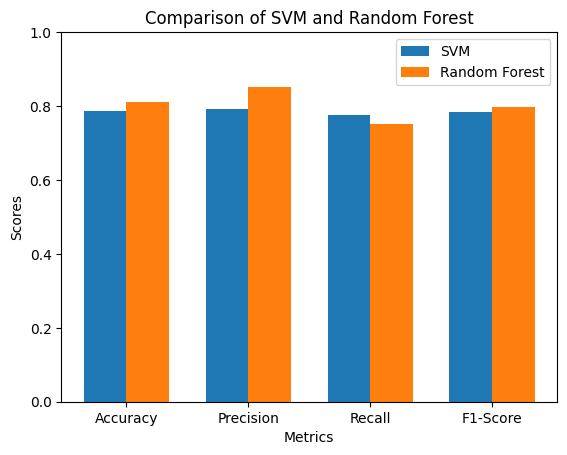

In [ ]:
# Plotting the comparison
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, svm_scores, width, label='SVM')
rects2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest')

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of SVM and Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.ylim(0, 1)
plt.show()

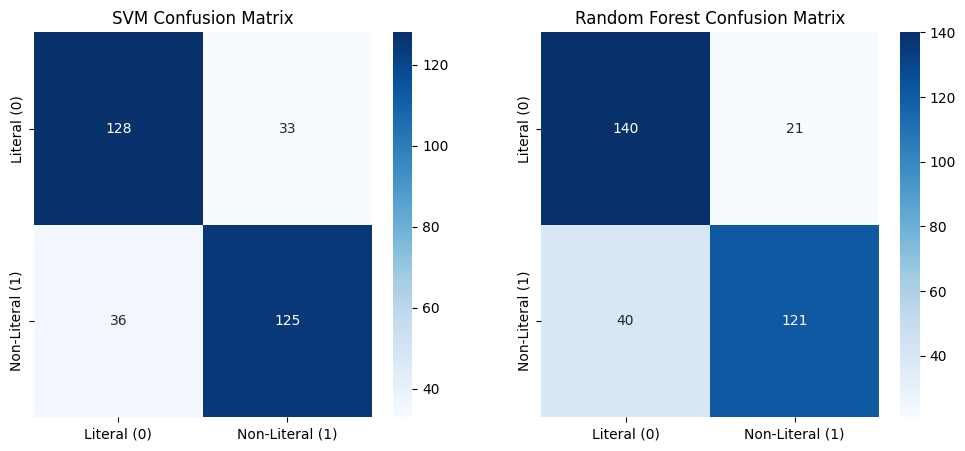

In [ ]:
# Plotting confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Literal (0)', 'Non-Literal (1)'], yticklabels=['Literal (0)', 'Non-Literal (1)'], ax=axes[0])
axes[0].set_title('SVM Confusion Matrix')
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Literal (0)', 'Non-Literal (1)'], yticklabels=['Literal (0)', 'Non-Literal (1)'], ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
plt.show()

## User Input & Output

In [ ]:
# Function for user input
def classify_sentence(sentence, model):
    sentence_vector = vectorizer.transform([sentence])
    sentence_pca = pca.transform(sentence_vector.toarray())
    sentence_selected = selector.transform(sentence_pca)
    prediction = model.predict(sentence_selected)[0]
    return prediction

In [ ]:
while True:
    user_input = input("Enter a sentence (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break
    print("Choose Model: 1 for SVM, 2 for Random Forest")
    model_choice = input("Enter model number: ")
    if model_choice == '1':
        prediction = classify_sentence(user_input, svm_best)
    elif model_choice == '2':
        prediction = classify_sentence(user_input, rf_best)
    else:
        print("Invalid choice. Defaulting to SVM.")
        prediction = classify_sentence(user_input, svm_best)
    label = "Non-Literal (1)" if prediction == 1 else "Literal (0)"
    print(f'{label}')

Enter a sentence (or type 'exit' to quit): Ayaw pagbuot kay lain-lain ta og lubot, respetaray lang ta sa atong mga opinion
Choose Model: 1 for SVM, 2 for Random Forest
Enter model number: 1
Literal (0)
Enter a sentence (or type 'exit' to quit): Ayaw pagbuot kay lain-lain ta og lubot, respetaray lang ta sa atong mga opinion
Choose Model: 1 for SVM, 2 for Random Forest
Enter model number: 2
Literal (0)
Enter a sentence (or type 'exit' to quit): exit
